<div style="padding:34px 38px;border-radius:18px;background:linear-gradient(135deg,#0b3558 0%,#1769aa 62%,#1b8a8f 100%);color:white;box-shadow:0 10px 30px rgba(11,53,88,.18);">
  <div style="font-size:13px;letter-spacing:1.8px;font-weight:700;opacity:.9;">UNIVERSIDAD DEL VALLE DE GUATEMALA · CC3066 DATA SCIENCE</div>
  <h1 style="font-size:34px;margin:14px 0 8px 0;color:white;">Proyecto 1 · Obtención y limpieza de datos</h1>
  <p style="font-size:19px;margin:0 0 20px 0;opacity:.95;">Establecimientos educativos de Guatemala con nivel Diversificado</p>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:10px;font-size:13px;line-height:1.55;">
    <div><b>Integrantes</b><br>Abby Sofia Donis Agreda · 22440<br>Pablo Daniel Barillas Moreno · 22193</div>
    <div><b>Equipo</b><br>Jorge Palacios · 231385<br>Roberto Emiliano Otoniel Camposeco Torres · 23968</div>
  </div>
  <div style="margin-top:18px;padding-top:14px;border-top:1px solid rgba(255,255,255,.35);font-size:13px;">Entrega final reproducible · 16 de julio de 2026</div>
</div>

## 1. Alcance, fuente y criterios de reproducibilidad

La unidad de observación es un **código de servicio educativo autorizado**, no necesariamente un edificio físico único. El archivo crudo procede del buscador de establecimientos del Ministerio de Educación de Guatemala:

<http://www.mineduc.gob.gt/BUSCAESTABLECIMIENTO_GE/>

El diagnóstico distingue faltantes técnicos y ausencias semánticas. Para una variable $X_j$, el porcentaje de ausencia se calcula mediante MathJax como:

$$
p_{\mathrm{faltante},j}=\frac{n_{\mathrm{faltante},j}}{n}\times 100.
$$

La limpieza sigue cuatro reglas de protección:

1. Los identificadores y teléfonos permanecen como texto.
2. Ninguna columna cruda se sobrescribe: se crean campos `*_ORIGINAL`, `*_LIMPIO`, códigos y estados.
3. Los nombres propios no se corrigen por similitud difusa; solo se aplican ajustes mecánicos, diccionarios explícitos o variantes acentuadas ya respaldadas por la fuente.
4. Una fila solo se eliminaría si fuera un duplicado exacto demostrado. En este conjunto no se elimina ninguna.


In [1]:
from pathlib import Path
from html import escape
import hashlib
import json
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

AZUL = "#1769aa"
AZUL_OSCURO = "#0b3558"
TURQUESA = "#1b8a8f"
NARANJA = "#e59b35"
GRIS = "#5f6b76"


class HTMLBlock:
    '''Objeto HTML portable: Jupyter lo renderiza y el ejecutor lo conserva como salida rica.'''

    def __init__(self, html):
        self.html = html

    def _repr_html_(self):
        return self.html

    def __repr__(self):
        return re.sub(r"<[^>]+>", " ", self.html)


CSS_TABLA = '''
<style>
.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
</style>
'''


def tabla_html(df, titulo, max_filas=25, nota=None):
    visible = df.head(max_filas).copy()
    table = visible.to_html(index=False, classes="ds-table", border=0, escape=True)
    pie = ""
    if len(df) > max_filas:
        pie += f"<p style='color:#5f6b76;font-size:12px'>Se muestran {max_filas} de {len(df):,} filas.</p>"
    if nota:
        pie += f"<div class='note'>{escape(str(nota))}</div>"
    return HTMLBlock(CSS_TABLA + f"<div class='ds-card'><h3>{escape(titulo)}</h3>{table}{pie}</div>")


def kpis_html(items):
    cards = "".join(
        f"<div class='kpi'><div class='label'>{escape(str(label))}</div><div class='value'>{escape(str(value))}</div></div>"
        for label, value in items
    )
    return HTMLBlock(CSS_TABLA + f"<div class='kpi-grid'>{cards}</div>")


def combinar_html(*objetos):
    return HTMLBlock(CSS_TABLA + "".join(obj.html if isinstance(obj, HTMLBlock) else str(obj) for obj in objetos))


print("Entorno de trabajo preparado correctamente.")


Entorno de trabajo preparado correctamente.


## 2. Carga protegida del conjunto crudo


In [2]:
RUTA_CANDIDATAS = [
    Path("datos_crudos_establecimientos_diversificado.csv"),
    Path("datos/datos_crudos_establecimientos_diversificado.csv"),
    Path("../datos/datos_crudos_establecimientos_diversificado.csv"),
    Path("datos_crudos_establecimientos_diversificado(1).csv"),
    Path("upload/datos_crudos_establecimientos_diversificado(1).csv"),
    Path("/content/datos_crudos_establecimientos_diversificado.csv"),
]
RUTA_DATOS = next((ruta for ruta in RUTA_CANDIDATAS if ruta.exists()), None)
if RUTA_DATOS is None:
    raise FileNotFoundError(
        "No se encontró el CSV crudo. Colóquelo junto al notebook con el nombre "
        "datos_crudos_establecimientos_diversificado.csv."
    )

SALIDAS = Path("salidas_proyecto_1")
DIR_DATOS = SALIDAS / "datos"
DIR_CRUDOS = SALIDAS / "datos_crudos_por_origen"
DIR_DOC = SALIDAS / "documentacion"
DIR_RESULTADOS = SALIDAS / "resultados"
for directorio in [DIR_DATOS, DIR_CRUDOS, DIR_DOC, DIR_RESULTADOS]:
    directorio.mkdir(parents=True, exist_ok=True)

datos = pd.read_csv(
    RUTA_DATOS,
    dtype="string",
    keep_default_na=False,
    encoding="utf-8",
)

COLUMNAS_ESPERADAS = [
    "CODIGO", "DISTRITO", "DEPARTAMENTO", "MUNICIPIO", "ESTABLECIMIENTO",
    "DIRECCION", "TELEFONO", "SUPERVISOR", "DIRECTOR", "NIVEL", "SECTOR",
    "AREA", "STATUS", "MODALIDAD", "JORNADA", "PLAN", "DEPARTAMENTAL",
]
assert datos.columns.tolist() == COLUMNAS_ESPERADAS

huella_crudo = hashlib.sha256(RUTA_DATOS.read_bytes()).hexdigest()
kpis_html([
    ("Registros crudos", f"{len(datos):,}"),
    ("Variables", datos.shape[1]),
    ("Códigos únicos", f"{datos['CODIGO'].nunique():,}"),
    ("SHA-256", huella_crudo[:12] + "…"),
])


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
   Registros crudos  11,603    Variables  17    Códigos únicos  11,603    SHA-256  e7b9f1056e17…

## 3. Diagnóstico del estado inicial

Se calculan dimensiones, tipo cargado, valores únicos, faltantes técnicos, ausencias semánticas, duplicados, dominios y formatos. `SIN JORNADA` y `SIN ESPECIFICAR` se registran como ausencias semánticas porque no representan jornadas o áreas reales, aunque se preservan literalmente en las columnas de origen.


In [3]:
MARCADORES_FALTANTES = {
    "--", "-", "N/A", "NA", "NO APLICA", "NO APLICA.", "NO TIENE", "NINGUNO", "NINGUNA",
    "SIN INFORMACION", "SIN INFORMACIÓN", "SIN DATO", "S/D", "S/N", "SN", "NULL", "NONE",
    "NO HAY", "DESCONOCIDO", ".",
}


def componentes_faltantes(serie, variable):
    texto = serie.astype("string").str.strip()
    mayusculas = texto.str.upper()
    tecnico = (
        texto.eq("")
        | mayusculas.isin(MARCADORES_FALTANTES)
        | mayusculas.str.fullmatch(r"[-._/]+", na=False)
    )
    semantico = pd.Series(False, index=serie.index)
    if variable == "AREA":
        semantico = mayusculas.eq("SIN ESPECIFICAR")
    elif variable == "JORNADA":
        semantico = mayusculas.eq("SIN JORNADA")
    return tecnico, semantico


filas_perfil = []
for variable in datos.columns:
    tecnico, semantico = componentes_faltantes(datos[variable], variable)
    faltantes = tecnico | semantico
    filas_perfil.append(
        {
            "VARIABLE": variable,
            "TIPO_CARGADO": str(datos[variable].dtype),
            "VALORES_UNICOS": int(datos[variable].nunique(dropna=False)),
            "FALTANTES_TECNICOS": int(tecnico.sum()),
            "AUSENCIAS_SEMANTICAS": int(semantico.sum()),
            "FALTANTES_ANALITICOS": int(faltantes.sum()),
            "PORCENTAJE_FALTANTE": round(100 * faltantes.mean(), 2),
        }
    )

perfil_crudo = pd.DataFrame(filas_perfil)
tabla_html(
    perfil_crudo,
    "Perfil completo de las 17 variables crudas",
    max_filas=17,
    nota="DIRECTOR presenta la mayor ausencia analítica; CODIGO conserva integridad completa.",
)


VARIABLE,TIPO_CARGADO,VALORES_UNICOS,FALTANTES_TECNICOS,AUSENCIAS_SEMANTICAS,FALTANTES_ANALITICOS,PORCENTAJE_FALTANTE
CODIGO,string,11603,0,0,0,0.00
DISTRITO,string,1667,522,0,522,4.50
DEPARTAMENTO,string,23,0,0,0,0.00
MUNICIPIO,string,350,0,0,0,0.00
ESTABLECIMIENTO,string,6170,5,0,5,0.04
DIRECCION,string,7260,87,0,87,0.75
TELEFONO,string,6429,933,0,933,8.04
SUPERVISOR,string,1268,525,0,525,4.52
DIRECTOR,string,5397,2106,0,2106,18.15
NIVEL,string,1,0,0,0,0.00


In [4]:
codigo_valido = datos["CODIGO"].str.strip().str.fullmatch(r"\d{2}-\d{2}-\d{4}-46", na=False)
distrito_valido = datos["DISTRITO"].str.strip().str.fullmatch(
    r"\d{2}-(?:\d{3}|\d{2}-\d{4})", na=False
)
telefono_8_digitos = datos["TELEFONO"].str.strip().str.fullmatch(r"\d{8}", na=False)
supervisor_espaciado = datos["SUPERVISOR"].str.strip().str.fullmatch(r"\S+(?: \S+)*", na=False)

dominios = {
    "NIVEL": {"DIVERSIFICADO"},
    "SECTOR": {"PRIVADO", "OFICIAL", "COOPERATIVA", "MUNICIPAL"},
    "AREA": {"URBANA", "RURAL", "SIN ESPECIFICAR"},
    "STATUS": {
        "ABIERTA", "CERRADA TEMPORALMENTE", "CERRADA DEFINITIVAMENTE",
        "TEMPORAL TITULOS", "TEMPORAL NOMBRAMIENTO",
    },
    "MODALIDAD": {"MONOLINGUE", "BILINGUE"},
    "JORNADA": {"DOBLE", "VESPERTINA", "MATUTINA", "SIN JORNADA", "NOCTURNA", "INTERMEDIA"},
}

filas_formato = [
    ("CODIGO", "##-##-####-46", int(codigo_valido.sum()), int((~codigo_valido).sum())),
    ("DISTRITO", "##-### o ##-##-####", int(distrito_valido.sum()), int((~distrito_valido).sum())),
    ("TELEFONO", "exactamente 8 dígitos", int(telefono_8_digitos.sum()), int((~telefono_8_digitos).sum())),
    ("SUPERVISOR", "espacio simple", int(supervisor_espaciado.sum()), int((~supervisor_espaciado).sum())),
]
formatos_crudos = pd.DataFrame(filas_formato, columns=["VARIABLE", "FORMATO", "CUMPLEN", "NO_CUMPLEN"])

fuera_dominio = pd.DataFrame(
    [
        {
            "VARIABLE": variable,
            "DOMINIO_OBSERVADO": len(set(datos[variable].str.strip().unique())),
            "VALORES_FUERA": int((~datos[variable].str.strip().isin(permitidos)).sum()),
        }
        for variable, permitidos in dominios.items()
    ]
)

duplicados_exactos = int(datos.duplicated().sum())
codigos_duplicados = int(datos["CODIGO"].duplicated().sum())
combinar_html(
    tabla_html(formatos_crudos, "Validación de formatos", max_filas=10),
    tabla_html(fuera_dominio, "Validación de dominios cerrados", max_filas=10),
    kpis_html([
        ("Duplicados exactos", duplicados_exactos),
        ("Códigos repetidos", codigos_duplicados),
        ("Categorías de origen", datos["DEPARTAMENTO"].nunique()),
        ("Municipios / zonas", datos["MUNICIPIO"].nunique()),
    ]),
)


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 

 
.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
  Validación de formatos  
   
     
       VARIABLE 
       FORMATO 
       CUMPLEN 
       NO_CUMPLEN 
     
   
   
     
       CODIGO 
       ##-##-####-46 
       11603 
       0 
     
     
       DISTRITO 
       ##-### o ##-##-#### 
       11012 
       591 
     
     
       TELEFONO 
       exactamente 8 dígitos 
       10420 
       1183 
     
     
       SUPERVISOR 
       espacio simple 
       11074 
       529 
     
   
  
 
.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
  Validación de dominios cerrados  
   
     
       VARIABLE 
       DOMINIO_OBSERVADO 
       VALORES_FUERA 
     
   
   
     
       NIVEL 
       1 
       0 
     
     
       SECTOR 
       4 
       0 
     
     
       AREA 
       3 
       0 
     
     
       STATUS 
       5 
       0 
     
     
       MODALIDAD 
       2 
       0 
     
     
       JORNADA 
       6 
       0 
     
   
  
 
.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,

## 4. Reglas definitivas de limpieza

<div style="display:grid;grid-template-columns:repeat(2,minmax(260px,1fr));gap:12px;">
  <div style="padding:15px;border-radius:10px;background:#eef5fb;border:1px solid #d7e4ee;"><b>Texto y ortografía</b><br>Unicode NFC, espacios, puntuación y capitalización española. Se restauran tildes mediante diccionarios explícitos o variantes equivalentes ya presentes en la fuente.</div>
  <div style="padding:15px;border-radius:10px;background:#eef8f7;border:1px solid #cfe8e4;"><b>Ausencias</b><br>`null` solo cuando no existe un valor utilizable. El original y el tipo de ausencia permanecen disponibles.</div>
  <div style="padding:15px;border-radius:10px;background:#fff8e8;border:1px solid #f0dfb7;"><b>Categorías</b><br>Etiquetas legibles y códigos nominales en columnas nuevas. Un código nunca se interpreta como escala.</div>
  <div style="padding:15px;border-radius:10px;background:#f7f4fb;border:1px solid #e1d7ee;"><b>Duplicados</b><br>CODIGO es la llave. Los nombres repetidos no se eliminan porque pueden corresponder a servicios, jornadas o sedes distintas.</div>
</div>


In [5]:
def normalizar_mecanico(valor):
    if pd.isna(valor):
        return pd.NA
    texto = unicodedata.normalize("NFC", str(valor)).replace("\u00a0", " ")
    texto = texto.replace("“", '"').replace("”", '"').replace("’", "'")
    texto = re.sub(r"\s+", " ", texto).strip()
    texto = re.sub(r"\s*([,;:])\s*", r"\1 ", texto)
    texto = re.sub(r"\s+([.)])", r"\1", texto)
    texto = re.sub(r"([(])\s+", r"\1", texto)
    return texto.strip()


def sin_tildes(valor):
    texto = unicodedata.normalize("NFD", str(valor))
    return "".join(c for c in texto if unicodedata.category(c) != "Mn")


def clave_comparacion(valor):
    if pd.isna(valor):
        return pd.NA
    texto = sin_tildes(normalizar_mecanico(valor)).upper()
    texto = re.sub(r"[^A-Z0-9]+", " ", texto)
    return re.sub(r"\s+", " ", texto).strip()


CORRECCIONES_PALABRAS = {
    "educacion": "educación", "tecnico": "técnico", "tecnica": "técnica",
    "tecnologico": "tecnológico", "tecnologica": "tecnológica",
    "computacion": "computación", "informatica": "informática",
    "administracion": "administración", "economicas": "económicas",
    "fisica": "física", "matematica": "matemática", "matematicas": "matemáticas",
    "mecanica": "mecánica", "electronica": "electrónica", "electricidad": "electricidad",
    "agronomia": "agronomía", "radiofonica": "radiofónica", "asociacion": "asociación",
    "catolico": "católico", "catolica": "católica", "corazon": "corazón",
    "publica": "pública", "publico": "público", "basico": "básico", "basica": "básica",
    "bilingue": "bilingüe", "monolingue": "monolingüe", "artistica": "artística",
    "musica": "música", "quimica": "química", "academico": "académico",
    "academica": "académica", "practica": "práctica", "practico": "práctico",
    "diversificacion": "diversificación", "orientacion": "orientación",
    "comunicacion": "comunicación", "formacion": "formación", "gestion": "gestión",
    "turistica": "turística", "gastronomia": "gastronomía", "ingles": "inglés",
    "frances": "francés", "pedagogia": "pedagogía", "psicologia": "psicología",
    "evangelico": "evangélico", "evangelica": "evangélica", "cientifico": "científico",
    "cientifica": "científica", "tecnologia": "tecnología", "pedagogico": "pedagógico",
    "pedagogica": "pedagógica", "superacion": "superación", "anonima": "anónima",
    "america": "América", "agricola": "agrícola", "mision": "misión", "vision": "visión",
    "jose": "José", "maria": "María", "jesus": "Jesús", "angel": "Ángel", "raul": "Raúl",
    "victor": "Víctor", "oscar": "Óscar", "hector": "Héctor", "cesar": "César",
    "efrain": "Efraín", "andres": "Andrés", "adrian": "Adrián", "cristobal": "Cristóbal",
    "sebastian": "Sebastián", "salomon": "Salomón",
    "gonzalez": "González", "perez": "Pérez", "lopez": "López", "martinez": "Martínez",
    "hernandez": "Hernández", "ramirez": "Ramírez", "rodriguez": "Rodríguez",
    "sanchez": "Sánchez", "vasquez": "Vásquez", "velasquez": "Velásquez",
    "dominguez": "Domínguez", "garcia": "García", "davila": "Dávila", "chavez": "Chávez",
    "mendez": "Méndez", "jimenez": "Jiménez", "juarez": "Juárez", "diaz": "Díaz",
    "gutierrez": "Gutiérrez", "alvarez": "Álvarez", "gomez": "Gómez", "munoz": "Muñoz",
    "caceres": "Cáceres", "cardenas": "Cárdenas", "merida": "Mérida", "mejia": "Mejía",
    "avila": "Ávila", "leon": "León",
    "marroquin": "Marroquín", "coban": "Cobán", "amatitlan": "Amatitlán",
    "malacatan": "Malacatán", "poptun": "Poptún", "gualan": "Gualán", "jocotan": "Jocotán",
    "camotan": "Camotán", "tecpan": "Tecpán", "patzun": "Patzún", "peten": "Petén",
    "quiche": "Quiché", "sacatepequez": "Sacatepéquez", "suchitepequez": "Suchitepéquez",
    "solola": "Sololá", "totonicapan": "Totonicapán",
    "tursmo": "turismo", "aviacon": "aviación", "intercultrual": "intercultural",
    "altaverapacencese": "altaverapacense", "avaenida": "avenida", "diagnonal": "diagonal",
}
CONECTORES = {"de", "del", "la", "las", "el", "los", "y", "e", "en", "para", "por", "a", "al"}
SIGLAS = {
    "INED", "INEB", "IGER", "CEEX", "CEMUCAF", "CONALFA", "PEM", "USAC", "UVG",
    "URL", "UMG", "ITC", "IPC", "IJA", "KINAL", "MINEDUC", "S.A.", "S.A", "ONG",
    "IIAV", "ITAN", "CENINFAV", "FMG", "ADS", "IMB", "PRONEA", "AMERG", "PC",
}


def acentuar_palabras(texto):
    partes = re.split(r"([^\wÁÉÍÓÚÜÑáéíóúüñ]+)", texto.lower())
    salida = []
    for parte in partes:
        clave = sin_tildes(parte).lower()
        salida.append(CORRECCIONES_PALABRAS.get(clave, parte))
    return "".join(salida)


def capitalizacion_espanola(texto):
    if pd.isna(texto):
        return pd.NA
    base = acentuar_palabras(normalizar_mecanico(texto)).title()
    tokens = base.split(" ")
    tokens = [token.lower() if i > 0 and token.lower() in CONECTORES else token for i, token in enumerate(tokens)]
    base = " ".join(tokens)
    for sigla in sorted(SIGLAS, key=len, reverse=True):
        base = re.sub(rf"(?<!\w){re.escape(sigla)}(?!\w)", sigla, base, flags=re.IGNORECASE)
    base = re.sub(r"\b([IVXLCDM]{1,6})\b", lambda m: m.group(1).upper(), base, flags=re.IGNORECASE)
    base = re.sub(r"\b(\d+)(Ra|Da|Ta)\.*", lambda m: m.group(1) + m.group(2).lower() + ".", base)
    return base


def mapa_canonico_acentos(serie):
    valores = serie.astype("string").map(normalizar_mecanico)
    conteos = valores.value_counts(dropna=True)
    candidatos = {}
    for valor, frecuencia in conteos.items():
        if not valor:
            continue
        clave = clave_comparacion(valor)
        acentos = sum(unicodedata.category(c) == "Mn" for c in unicodedata.normalize("NFD", valor))
        puntaje = (acentos, int(frecuencia), len(valor))
        if clave not in candidatos or puntaje > candidatos[clave][0]:
            candidatos[clave] = (puntaje, valor)
    return {clave: valor for clave, (_, valor) in candidatos.items()}


def limpiar_texto_con_canon(serie, canon=None, nulos=None):
    nulos = nulos or set()
    salida = []
    for valor in serie:
        mecanico = normalizar_mecanico(valor)
        if not mecanico or mecanico.upper() in nulos or re.fullmatch(r"[-._/]+", mecanico):
            salida.append(pd.NA)
            continue
        if canon:
            mecanico = canon.get(clave_comparacion(mecanico), mecanico)
        salida.append(capitalizacion_espanola(mecanico))
    return pd.Series(salida, index=serie.index, dtype="string")


MAPA_DEPARTAMENTOS = {
    "CIUDAD CAPITAL": "Ciudad Capital", "GUATEMALA": "Guatemala", "EL PROGRESO": "El Progreso",
    "SACATEPEQUEZ": "Sacatepéquez", "CHIMALTENANGO": "Chimaltenango", "ESCUINTLA": "Escuintla",
    "SANTA ROSA": "Santa Rosa", "SOLOLA": "Sololá", "TOTONICAPAN": "Totonicapán",
    "QUETZALTENANGO": "Quetzaltenango", "SUCHITEPEQUEZ": "Suchitepéquez", "RETALHULEU": "Retalhuleu",
    "SAN MARCOS": "San Marcos", "HUEHUETENANGO": "Huehuetenango", "QUICHE": "Quiché",
    "BAJA VERAPAZ": "Baja Verapaz", "ALTA VERAPAZ": "Alta Verapaz", "PETEN": "Petén",
    "IZABAL": "Izabal", "ZACAPA": "Zacapa", "CHIQUIMULA": "Chiquimula", "JALAPA": "Jalapa",
    "JUTIAPA": "Jutiapa",
}
CODIGOS_DEPARTAMENTO = {
    "Guatemala": "01", "El Progreso": "02", "Sacatepéquez": "03", "Chimaltenango": "04",
    "Escuintla": "05", "Santa Rosa": "06", "Sololá": "07", "Totonicapán": "08",
    "Quetzaltenango": "09", "Suchitepéquez": "10", "Retalhuleu": "11", "San Marcos": "12",
    "Huehuetenango": "13", "Quiché": "14", "Baja Verapaz": "15", "Alta Verapaz": "16",
    "Petén": "17", "Izabal": "18", "Zacapa": "19", "Chiquimula": "20", "Jalapa": "21",
    "Jutiapa": "22",
}

CATALOGOS = {
    "SECTOR": {"PRIVADO": ("Privado", 1), "OFICIAL": ("Oficial", 2), "COOPERATIVA": ("Cooperativa", 3), "MUNICIPAL": ("Municipal", 4)},
    "AREA": {"URBANA": ("Urbana", 1), "RURAL": ("Rural", 2)},
    "STATUS": {
        "ABIERTA": ("Abierta", 1), "CERRADA TEMPORALMENTE": ("Cerrada temporalmente", 2),
        "CERRADA DEFINITIVAMENTE": ("Cerrada definitivamente", 3),
        "TEMPORAL TITULOS": ("Temporal por títulos", 4),
        "TEMPORAL NOMBRAMIENTO": ("Temporal por nombramiento", 5),
    },
    "MODALIDAD": {"MONOLINGUE": ("Monolingüe", 1), "BILINGUE": ("Bilingüe", 2)},
    "JORNADA": {
        "MATUTINA": ("Matutina", 1), "VESPERTINA": ("Vespertina", 2), "NOCTURNA": ("Nocturna", 3),
        "DOBLE": ("Doble", 4), "INTERMEDIA": ("Intermedia", 5),
    },
}

PLAN_ORDEN = [
    "DIARIO(REGULAR)", "FIN DE SEMANA", "SEMIPRESENCIAL (FIN DE SEMANA)",
    "SEMIPRESENCIAL (UN DÍA A LA SEMANA)", "A DISTANCIA", "SEMIPRESENCIAL",
    "SEMIPRESENCIAL (DOS DÍAS A LA SEMANA)", "VIRTUAL A DISTANCIA", "SABATINO",
    "DOMINICAL", "MIXTO", "IRREGULAR", "INTERCALADO",
]
PLAN_ETIQUETAS = {
    valor: ("Diario (regular)" if valor == "DIARIO(REGULAR)" else capitalizacion_espanola(valor))
    for valor in PLAN_ORDEN
}
PLAN_CODIGOS = {valor: i + 1 for i, valor in enumerate(PLAN_ORDEN)}


def extraer_telefonos(valor):
    texto = normalizar_mecanico(valor)
    if not texto:
        return []
    digitos = re.sub(r"\D", "", texto)
    if len(digitos) >= 11 and digitos.startswith("502") and (len(digitos) - 3) % 8 == 0:
        digitos = digitos[3:]
    if digitos and len(digitos) % 8 == 0:
        return [digitos[i:i + 8] for i in range(0, len(digitos), 8)]
    return re.findall(r"(?<!\d)\d{8}(?!\d)", texto)


def formato_telefono(numero):
    return f"{numero[:4]}-{numero[4:]}"


print("Diccionarios y funciones de limpieza definidos.")


Diccionarios y funciones de limpieza definidos.


## 5. Ejecución de la limpieza y construcción de la vista nacional


In [6]:
canon_establecimiento = mapa_canonico_acentos(datos["ESTABLECIMIENTO"])
canon_direccion = mapa_canonico_acentos(datos["DIRECCION"])
canon_supervisor = mapa_canonico_acentos(datos["SUPERVISOR"])
canon_director = mapa_canonico_acentos(datos["DIRECTOR"])
canon_municipio = mapa_canonico_acentos(datos["MUNICIPIO"])

limpio = pd.DataFrame(index=datos.index)
limpio["CODIGO"] = datos["CODIGO"].astype("string").str.strip()

limpio["DISTRITO_ORIGINAL"] = datos["DISTRITO"].astype("string")
distrito_texto = datos["DISTRITO"].astype("string").str.strip()
distrito_completo = distrito_texto.str.fullmatch(r"\d{2}-(?:\d{3}|\d{2}-\d{4})", na=False)
limpio["DISTRITO_LIMPIO"] = distrito_texto.where(distrito_completo, pd.NA)
limpio["DISTRITO_ESTADO"] = pd.Series(
    np.select([distrito_texto.eq(""), distrito_completo], ["Vacío", "Válido"], default="Incompleto"),
    dtype="string",
)

limpio["DEPARTAMENTO_ORIGINAL"] = datos["DEPARTAMENTO"].astype("string")
limpio["DEPARTAMENTO_LIMPIO"] = datos["DEPARTAMENTO"].map(MAPA_DEPARTAMENTOS).astype("string")
limpio["DEPARTAMENTO_ANALISIS"] = limpio["DEPARTAMENTO_LIMPIO"].replace({"Ciudad Capital": "Guatemala"})
limpio["DEPARTAMENTO_ANALISIS_COD"] = limpio["DEPARTAMENTO_ANALISIS"].map(CODIGOS_DEPARTAMENTO).astype("string")

limpio["MUNICIPIO_ORIGINAL"] = datos["MUNICIPIO"].astype("string")
limpio["MUNICIPIO_LIMPIO"] = limpiar_texto_con_canon(datos["MUNICIPIO"], canon_municipio)
es_capital = datos["DEPARTAMENTO"].eq("CIUDAD CAPITAL")
limpio["UBICACION_GRUPO"] = pd.Series(np.where(es_capital, "Ciudad Capital", "Otros municipios"), dtype="string")
limpio["TIPO_UBICACION"] = pd.Series(np.where(es_capital, "Zona capital", "Municipio"), dtype="string")
limpio["ES_CIUDAD_CAPITAL"] = es_capital.astype("Int8")
limpio["ZONA_CAPITAL_COD"] = pd.to_numeric(
    datos["MUNICIPIO"].str.extract(r"ZONA\s+(\d+)", expand=False).where(es_capital), errors="coerce"
).astype("Int8")
limpio["MUNICIPIO_COD_FUENTE"] = limpio["CODIGO"].str.slice(0, 5).where(~es_capital, pd.NA)

limpio["ESTABLECIMIENTO_ORIGINAL"] = datos["ESTABLECIMIENTO"].astype("string")
limpio["ESTABLECIMIENTO_LIMPIO"] = limpiar_texto_con_canon(datos["ESTABLECIMIENTO"], canon_establecimiento)
limpio["ESTABLECIMIENTO_CLAVE_COMPARACION"] = limpio["ESTABLECIMIENTO_LIMPIO"].map(clave_comparacion).astype("string")

limpio["DIRECCION_ORIGINAL"] = datos["DIRECCION"].astype("string")
limpio["DIRECCION_LIMPIA"] = limpiar_texto_con_canon(datos["DIRECCION"], canon_direccion)

limpio["TELEFONO_ORIGINAL"] = datos["TELEFONO"].astype("string")
telefonos_extraidos = datos["TELEFONO"].map(extraer_telefonos)
telefono_vacio = datos["TELEFONO"].astype("string").str.strip().eq("")
limpio["TELEFONO_LIMPIO"] = pd.Series(
    [
        pd.NA if vacio else " | ".join(formato_telefono(n) for n in nums) if nums else normalizar_mecanico(raw)
        for raw, nums, vacio in zip(datos["TELEFONO"], telefonos_extraidos, telefono_vacio)
    ],
    dtype="string",
)
limpio["TELEFONO_PRINCIPAL"] = pd.Series(
    [formato_telefono(nums[0]) if nums else pd.NA for nums in telefonos_extraidos], dtype="string"
)
limpio["TELEFONO_ESTADO"] = pd.Series(
    [
        "Vacío" if vacio else "Válido único" if len(nums) == 1 else "Válidos múltiples" if len(nums) > 1 else "Formato no estándar"
        for nums, vacio in zip(telefonos_extraidos, telefono_vacio)
    ],
    dtype="string",
)

limpio["SUPERVISOR_ORIGINAL"] = datos["SUPERVISOR"].astype("string")
limpio["SUPERVISOR_LIMPIO"] = limpiar_texto_con_canon(datos["SUPERVISOR"], canon_supervisor)
limpio["DIRECTOR_ORIGINAL"] = datos["DIRECTOR"].astype("string")
limpio["DIRECTOR_LIMPIO"] = limpiar_texto_con_canon(
    datos["DIRECTOR"], canon_director, nulos=MARCADORES_FALTANTES
)
director_raw = datos["DIRECTOR"].astype("string").str.strip()
limpio["DIRECTOR_ESTADO"] = pd.Series(
    np.select(
        [director_raw.eq(""), director_raw.str.upper().isin(MARCADORES_FALTANTES) | director_raw.str.fullmatch(r"[-._/]+", na=False)],
        ["Vacío", "Marcador"],
        default="Informado",
    ),
    dtype="string",
)

limpio["NIVEL_ORIGINAL"] = datos["NIVEL"].astype("string")
limpio["NIVEL_LIMPIO"] = datos["NIVEL"].replace({"DIVERSIFICADO": "Diversificado"}).astype("string")

for variable in ["SECTOR", "STATUS"]:
    limpio[f"{variable}_ORIGINAL"] = datos[variable].astype("string")
    limpio[f"{variable}_LIMPIO"] = datos[variable].map({k: v[0] for k, v in CATALOGOS[variable].items()}).astype("string")
    limpio[f"{variable}_COD"] = datos[variable].map({k: v[1] for k, v in CATALOGOS[variable].items()}).astype("Int8")

limpio["MODALIDAD_ORIGINAL"] = datos["MODALIDAD"].astype("string")
limpio["MODALIDAD_LIMPIA"] = datos["MODALIDAD"].map(
    {k: v[0] for k, v in CATALOGOS["MODALIDAD"].items()}
).astype("string")
limpio["MODALIDAD_COD"] = datos["MODALIDAD"].map(
    {k: v[1] for k, v in CATALOGOS["MODALIDAD"].items()}
).astype("Int8")

limpio["AREA_ORIGINAL"] = datos["AREA"].astype("string")
limpio["AREA_LIMPIA"] = datos["AREA"].map({k: v[0] for k, v in CATALOGOS["AREA"].items()}).astype("string")
limpio["AREA_COD"] = datos["AREA"].map({k: v[1] for k, v in CATALOGOS["AREA"].items()}).astype("Int8")
limpio["AREA_INFORMADA"] = limpio["AREA_LIMPIA"].notna().astype("Int8")

limpio["JORNADA_ORIGINAL"] = datos["JORNADA"].astype("string")
limpio["JORNADA_LIMPIA"] = datos["JORNADA"].map({k: v[0] for k, v in CATALOGOS["JORNADA"].items()}).astype("string")
limpio["JORNADA_COD"] = datos["JORNADA"].map({k: v[1] for k, v in CATALOGOS["JORNADA"].items()}).astype("Int8")
limpio["JORNADA_INFORMADA"] = limpio["JORNADA_LIMPIA"].notna().astype("Int8")

limpio["PLAN_ORIGINAL"] = datos["PLAN"].astype("string")
limpio["PLAN_LIMPIO"] = datos["PLAN"].map(PLAN_ETIQUETAS).astype("string")
limpio["PLAN_COD"] = datos["PLAN"].map(PLAN_CODIGOS).astype("Int8")

limpio["DEPARTAMENTAL_ORIGINAL"] = datos["DEPARTAMENTAL"].astype("string")
limpio["DEPARTAMENTAL_LIMPIO"] = limpiar_texto_con_canon(datos["DEPARTAMENTAL"])
departamental_orden = sorted(limpio["DEPARTAMENTAL_LIMPIO"].dropna().unique())
departamental_codigos = {valor: i + 1 for i, valor in enumerate(departamental_orden)}
limpio["DEPARTAMENTAL_COD"] = limpio["DEPARTAMENTAL_LIMPIO"].map(departamental_codigos).astype("Int8")

limpio["FUENTE"] = pd.Series(
    "MINEDUC - Búsqueda de centros educativos autorizados",
    index=limpio.index,
    dtype="string",
)
limpio["FECHA_PROCESAMIENTO"] = pd.Series("2026-07-16", index=limpio.index, dtype="string")

kpis_html([
    ("Filas antes", f"{len(datos):,}"),
    ("Filas después", f"{len(limpio):,}"),
    ("Columnas finales", limpio.shape[1]),
    ("Filas eliminadas", len(datos) - len(limpio)),
])


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
   Filas antes  11,603    Filas después  11,603    Columnas finales  56    Filas eliminadas  0

## 6. Bitácora, catálogos y libro de códigos


In [7]:
def diferentes(original, limpio_serie):
    a = original.astype("string").fillna("<NULL>")
    b = limpio_serie.astype("string").fillna("<NULL>")
    return a.ne(b)


reglas = [
    ("R01", "Todas", "Carga como texto y conservación del esquema crudo.", "Evitar pérdida de ceros, guiones y etiquetas.", "Conversión automática por software.", "Validar 17 columnas y 11,603 filas.", len(datos)),
    ("R02", "Campos textuales", "Unicode NFC, trim, espacios y puntuación.", "Presentación consistente y reversible.", "Alterar puntuación legítima.", "Conservar original y registrar diferencias.", int(sum(diferentes(datos[c], datos[c].map(normalizar_mecanico)).sum() for c in datos.columns))),
    ("R03", "DISTRITO", "Null para vacíos o formatos incompletos; estado separado.", "No inventar distritos.", "Perder el prefijo parcial en análisis.", "Mantener DISTRITO_ORIGINAL y DISTRITO_ESTADO.", int(limpio["DISTRITO_LIMPIO"].isna().sum())),
    ("R04", "DEPARTAMENTO/MUNICIPIO", "Etiquetas legibles y geografía de 23 orígenes / 22 departamentos.", "Evitar doble conteo de Ciudad Capital.", "Fusionar procedencias.", "Conservar DEPARTAMENTO_ORIGINAL.", len(datos)),
    ("R05", "ESTABLECIMIENTO", "Capitalización española, tildes respaldadas y clave auxiliar.", "Producir nombres utilizables sin deduplicar por similitud.", "Corregir un nombre propio sin evidencia.", "Original permanente; no reemplazo por similitud difusa.", int(diferentes(datos["ESTABLECIMIENTO"], limpio["ESTABLECIMIENTO_LIMPIO"]).sum())),
    ("R06", "DIRECCION", "Normalización conservadora; null solo en vacíos o puntuación aislada.", "Mejorar lectura sin perder referencias.", "Modificar abreviaturas válidas.", "Conservar DIRECCION_ORIGINAL.", int(diferentes(datos["DIRECCION"], limpio["DIRECCION_LIMPIA"]).sum())),
    ("R07", "TELEFONO", "Texto normalizado, extracción de candidatos y estado.", "No tratar teléfonos como cantidades.", "Inventar dígitos faltantes.", "Los formatos históricos se conservan como texto.", int(diferentes(datos["TELEFONO"], limpio["TELEFONO_LIMPIO"]).sum())),
    ("R08", "SUPERVISOR/DIRECTOR", "Null para ausencias y presentación conservadora.", "Separar ausencia de nombres informados.", "Fusionar homónimos.", "No se asignan identificadores de persona.", int(limpio["SUPERVISOR_LIMPIO"].isna().sum() + limpio["DIRECTOR_LIMPIO"].isna().sum())),
    ("R09", "AREA", "SIN ESPECIFICAR a null en AREA_LIMPIA; indicador y original.", "No presentarlo como tercera área.", "Perder la razón del null.", "AREA_ORIGINAL y AREA_INFORMADA.", int(limpio["AREA_LIMPIA"].isna().sum())),
    ("R10", "JORNADA", "SIN JORNADA a null en JORNADA_LIMPIA; indicador y original.", "Analizar solo jornadas reales.", "Perder la razón del null.", "JORNADA_ORIGINAL y JORNADA_INFORMADA.", int(limpio["JORNADA_LIMPIA"].isna().sum())),
    ("R11", "Categorías", "Códigos nominales estables en columnas nuevas.", "Evitar inconsistencias posteriores.", "Interpretar códigos como orden.", "Etiquetas legibles y catálogos separados.", len(datos)),
    ("R12", "Duplicados", "No eliminar filas: CODIGO es único y no hay duplicados exactos.", "Preservar servicios legítimos.", "Confundir nombres repetidos con duplicados.", "Pruebas de llave y duplicado exacto.", 0),
]
bitacora_resumen = pd.DataFrame(
    reglas,
    columns=["REGLA_ID", "VARIABLES", "ACCION", "RAZON", "RIESGO", "CONTROL", "FILAS_AFECTADAS"],
)

pares_cambio = [
    ("DISTRITO", "DISTRITO_LIMPIO", "R03"), ("DEPARTAMENTO", "DEPARTAMENTO_LIMPIO", "R04"),
    ("MUNICIPIO", "MUNICIPIO_LIMPIO", "R04"), ("ESTABLECIMIENTO", "ESTABLECIMIENTO_LIMPIO", "R05"),
    ("DIRECCION", "DIRECCION_LIMPIA", "R06"), ("TELEFONO", "TELEFONO_LIMPIO", "R07"),
    ("SUPERVISOR", "SUPERVISOR_LIMPIO", "R08"), ("DIRECTOR", "DIRECTOR_LIMPIO", "R08"),
    ("NIVEL", "NIVEL_LIMPIO", "R11"), ("SECTOR", "SECTOR_LIMPIO", "R11"),
    ("AREA", "AREA_LIMPIA", "R09"), ("STATUS", "STATUS_LIMPIO", "R11"),
    ("MODALIDAD", "MODALIDAD_LIMPIA", "R11"), ("JORNADA", "JORNADA_LIMPIA", "R10"),
    ("PLAN", "PLAN_LIMPIO", "R11"), ("DEPARTAMENTAL", "DEPARTAMENTAL_LIMPIO", "R11"),
]
detalle_partes = []
for original_col, limpio_col, regla_id in pares_cambio:
    mascara = diferentes(datos[original_col], limpio[limpio_col])
    if mascara.any():
        detalle_partes.append(
            pd.DataFrame(
                {
                    "CODIGO": limpio.loc[mascara, "CODIGO"],
                    "VARIABLE": original_col,
                    "VALOR_ORIGINAL": datos.loc[mascara, original_col],
                    "VALOR_LIMPIO": limpio.loc[mascara, limpio_col],
                    "REGLA_ID": regla_id,
                    "FECHA_PROCESAMIENTO": "2026-07-16",
                }
            )
        )
bitacora_detalle = pd.concat(detalle_partes, ignore_index=True)

catalogos_filas = []
for variable, catalogo in CATALOGOS.items():
    for original, (etiqueta, codigo) in catalogo.items():
        catalogos_filas.append((variable, original, etiqueta, codigo, "Código nominal"))
for original in PLAN_ORDEN:
    catalogos_filas.append(("PLAN", original, PLAN_ETIQUETAS[original], PLAN_CODIGOS[original], "Código nominal"))
for etiqueta, codigo in CODIGOS_DEPARTAMENTO.items():
    catalogos_filas.append(("DEPARTAMENTO_ANALISIS", etiqueta, etiqueta, codigo, "Código territorial"))
for etiqueta, codigo in departamental_codigos.items():
    catalogos_filas.append(("DEPARTAMENTAL", etiqueta.upper(), etiqueta, codigo, "Código nominal"))
catalogos = pd.DataFrame(
    catalogos_filas,
    columns=["VARIABLE", "VALOR_ORIGINAL", "ETIQUETA_LIMPIA", "CODIGO", "TIPO_CODIGO"],
)

DESCRIPCIONES_CRUDAS = {
    "DISTRITO": "Código de distrito o supervisión educativa publicado por la fuente.",
    "DEPARTAMENTO": "Categoría territorial de origen utilizada por el portal.",
    "MUNICIPIO": "Municipio o zona de Ciudad Capital publicado por el portal.",
    "ESTABLECIMIENTO": "Nombre registrado del establecimiento educativo.",
    "DIRECCION": "Dirección textual publicada.", "TELEFONO": "Uno o varios contactos telefónicos publicados.",
    "SUPERVISOR": "Nombre de la persona supervisora publicada.", "DIRECTOR": "Nombre de la persona directora publicada.",
    "NIVEL": "Nivel educativo consultado.", "SECTOR": "Sector administrativo del servicio.",
    "AREA": "Área territorial urbana o rural.", "STATUS": "Estado administrativo del servicio.",
    "MODALIDAD": "Modalidad lingüística.", "JORNADA": "Jornada autorizada.",
    "PLAN": "Plan o modalidad temporal de atención.", "DEPARTAMENTAL": "Dirección departamental responsable.",
}
DESCRIPCIONES_DERIVADAS = {
    "CODIGO": "Identificador textual único del servicio educativo autorizado.",
    "DISTRITO_LIMPIO": "Distrito completo; null cuando la fuente está vacía o incompleta.",
    "DISTRITO_ESTADO": "Clasificación de completitud del distrito: Válido, Vacío o Incompleto.",
    "DEPARTAMENTO_LIMPIO": "Categoría de origen con presentación ortográfica.",
    "DEPARTAMENTO_ANALISIS": "Departamento analítico de 22 categorías; Ciudad Capital se agrega a Guatemala.",
    "DEPARTAMENTO_ANALISIS_COD": "Código territorial de dos dígitos del departamento analítico.",
    "MUNICIPIO_LIMPIO": "Municipio o zona con presentación normalizada.",
    "UBICACION_GRUPO": "Distingue Ciudad Capital de otros municipios.",
    "TIPO_UBICACION": "Indica si la etiqueta territorial es Zona capital o Municipio.",
    "ES_CIUDAD_CAPITAL": "Indicador binario: 1 para Ciudad Capital y 0 para otros municipios.",
    "ZONA_CAPITAL_COD": "Número de zona de Ciudad Capital; null fuera de la capital.",
    "MUNICIPIO_COD_FUENTE": "Prefijo departamento-municipio del CODIGO; null para zonas capitalinas.",
    "ESTABLECIMIENTO_LIMPIO": "Nombre de presentación con ortografía conservadora y trazable.",
    "ESTABLECIMIENTO_CLAVE_COMPARACION": "Clave sin tildes ni puntuación usada solo para detectar candidatos.",
    "DIRECCION_LIMPIA": "Dirección de presentación; null cuando no existe contenido utilizable.",
    "TELEFONO_LIMPIO": "Texto telefónico normalizado; conserva formatos históricos no interpretables.",
    "TELEFONO_PRINCIPAL": "Primer candidato de ocho dígitos con formato ####-####.",
    "TELEFONO_ESTADO": "Estado de interpretación del teléfono.",
    "SUPERVISOR_LIMPIO": "Nombre de supervisión de presentación o null.",
    "DIRECTOR_LIMPIO": "Nombre de dirección de presentación o null.",
    "DIRECTOR_ESTADO": "Informado, Vacío o Marcador.",
    "NIVEL_LIMPIO": "Nivel Diversificado con etiqueta legible.",
    "SECTOR_LIMPIO": "Etiqueta de sector legible.", "SECTOR_COD": "Código nominal del sector.",
    "AREA_LIMPIA": "Urbana o Rural; null para SIN ESPECIFICAR.", "AREA_COD": "Código nominal del área.",
    "AREA_INFORMADA": "Indicador binario de área informada.",
    "STATUS_LIMPIO": "Estado administrativo con etiqueta legible.", "STATUS_COD": "Código nominal del estado.",
    "MODALIDAD_LIMPIA": "Modalidad con ortografía corregida.", "MODALIDAD_COD": "Código nominal de modalidad.",
    "JORNADA_LIMPIA": "Jornada real; null para SIN JORNADA.", "JORNADA_COD": "Código nominal de jornada real.",
    "JORNADA_INFORMADA": "Indicador binario de jornada informada.",
    "PLAN_LIMPIO": "Plan con presentación normalizada.", "PLAN_COD": "Código nominal del plan.",
    "DEPARTAMENTAL_LIMPIO": "Dirección departamental con presentación ortográfica.",
    "DEPARTAMENTAL_COD": "Código nominal de dirección departamental.",
    "FUENTE": "Nombre de la fuente administrativa.", "FECHA_PROCESAMIENTO": "Fecha reproducible de esta versión final.",
}


def dominio_variable(columna):
    if columna.endswith("_ORIGINAL"):
        return "Texto publicado por MINEDUC; se conserva sin sobrescritura."
    if columna.endswith("_COD"):
        return "Catálogo documentado; identificador nominal salvo código territorial."
    if columna in {"ES_CIUDAD_CAPITAL", "AREA_INFORMADA", "JORNADA_INFORMADA"}:
        return "0 = No; 1 = Sí."
    if columna == "DEPARTAMENTO_ANALISIS":
        return "22 departamentos de Guatemala."
    if columna == "UBICACION_GRUPO":
        return "Ciudad Capital; Otros municipios."
    if columna == "TIPO_UBICACION":
        return "Zona capital; Municipio."
    return "Véase descripción y catálogo cuando corresponda."


filas_codigo = []
for columna in limpio.columns:
    if columna.endswith("_ORIGINAL"):
        base = columna.removesuffix("_ORIGINAL")
        descripcion = "Valor original: " + DESCRIPCIONES_CRUDAS[base]
        regla = "Conservación del valor crudo"
    else:
        descripcion = DESCRIPCIONES_DERIVADAS[columna]
        regla = "Derivación documentada"
    ejemplo_serie = limpio[columna].dropna()
    ejemplo = str(ejemplo_serie.iloc[0]) if len(ejemplo_serie) else ""
    filas_codigo.append(
        {
            "VARIABLE": columna,
            "DESCRIPCION": descripcion,
            "TIPO": str(limpio[columna].dtype),
            "ADMITE_NULL": "Sí" if limpio[columna].isna().any() else "No",
            "DOMINIO_VALORES": dominio_variable(columna),
            "ORIGEN_REGLA": regla,
            "EJEMPLO": ejemplo,
        }
    )
libro_codigos = pd.DataFrame(filas_codigo)
assert set(libro_codigos["VARIABLE"]) == set(limpio.columns)

kpis_html([
    ("Reglas documentadas", len(bitacora_resumen)),
    ("Cambios trazados", f"{len(bitacora_detalle):,}"),
    ("Valores de catálogo", len(catalogos)),
    ("Variables finales", len(libro_codigos)),
])


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
   Reglas documentadas  12    Cambios trazados  174,511    Valores de catálogo  79    Variables finales  56

## 7. Controles de calidad y criterios de aceptación


In [8]:
controles = [
    ("QC01", "Filas conservadas", len(limpio) == len(datos), len(datos), len(limpio)),
    ("QC02", "CODIGO único", limpio["CODIGO"].is_unique, len(datos), limpio["CODIGO"].nunique()),
    ("QC03", "CODIGO con patrón", bool(limpio["CODIGO"].str.fullmatch(r"\d{2}-\d{2}-\d{4}-46", na=False).all()), len(datos), int(limpio["CODIGO"].str.fullmatch(r"\d{2}-\d{2}-\d{4}-46", na=False).sum())),
    ("QC04", "Duplicados exactos crudos", duplicados_exactos == 0, 0, duplicados_exactos),
    ("QC05", "Categorías de origen", limpio["DEPARTAMENTO_ORIGINAL"].nunique() == 23, 23, limpio["DEPARTAMENTO_ORIGINAL"].nunique()),
    ("QC06", "Departamentos analíticos", limpio["DEPARTAMENTO_ANALISIS"].nunique() == 22, 22, limpio["DEPARTAMENTO_ANALISIS"].nunique()),
    ("QC07", "Filas Ciudad Capital", int(limpio["ES_CIUDAD_CAPITAL"].sum()) == 2161, 2161, int(limpio["ES_CIUDAD_CAPITAL"].sum())),
    ("QC08", "Null en DISTRITO_LIMPIO", int(limpio["DISTRITO_LIMPIO"].isna().sum()) == 591, 591, int(limpio["DISTRITO_LIMPIO"].isna().sum())),
    ("QC09", "Null en ESTABLECIMIENTO_LIMPIO", int(limpio["ESTABLECIMIENTO_LIMPIO"].isna().sum()) == 5, 5, int(limpio["ESTABLECIMIENTO_LIMPIO"].isna().sum())),
    ("QC10", "Null en DIRECCION_LIMPIA", int(limpio["DIRECCION_LIMPIA"].isna().sum()) == 87, 87, int(limpio["DIRECCION_LIMPIA"].isna().sum())),
    ("QC11", "Null en TELEFONO_LIMPIO", int(limpio["TELEFONO_LIMPIO"].isna().sum()) == 933, 933, int(limpio["TELEFONO_LIMPIO"].isna().sum())),
    ("QC12", "Null en SUPERVISOR_LIMPIO", int(limpio["SUPERVISOR_LIMPIO"].isna().sum()) == 525, 525, int(limpio["SUPERVISOR_LIMPIO"].isna().sum())),
    ("QC13", "Null en DIRECTOR_LIMPIO", int(limpio["DIRECTOR_LIMPIO"].isna().sum()) == 2106, 2106, int(limpio["DIRECTOR_LIMPIO"].isna().sum())),
    ("QC14", "Null en AREA_LIMPIA", int(limpio["AREA_LIMPIA"].isna().sum()) == 3, 3, int(limpio["AREA_LIMPIA"].isna().sum())),
    ("QC15", "Null en JORNADA_LIMPIA", int(limpio["JORNADA_LIMPIA"].isna().sum()) == 1072, 1072, int(limpio["JORNADA_LIMPIA"].isna().sum())),
    ("QC16", "Códigos sector completos", int(limpio["SECTOR_COD"].isna().sum()) == 0, 0, int(limpio["SECTOR_COD"].isna().sum())),
    ("QC17", "Códigos status completos", int(limpio["STATUS_COD"].isna().sum()) == 0, 0, int(limpio["STATUS_COD"].isna().sum())),
]
control_calidad = pd.DataFrame(controles, columns=["CONTROL_ID", "CONTROL", "CUMPLE", "ESPERADO", "OBSERVADO"])
if not bool(control_calidad["CUMPLE"].all()):
    raise AssertionError(control_calidad.loc[~control_calidad["CUMPLE"]].to_string(index=False))

tabla_html(
    control_calidad.assign(RESULTADO=np.where(control_calidad["CUMPLE"], "APROBADO", "REVISAR")),
    "Pruebas automáticas de aceptación",
    max_filas=30,
    nota="Todas las pruebas deben aprobarse antes de exportar la entrega final.",
)


CONTROL_ID,CONTROL,CUMPLE,ESPERADO,OBSERVADO,RESULTADO
QC01,Filas conservadas,True,11603,11603,APROBADO
QC02,CODIGO único,True,11603,11603,APROBADO
QC03,CODIGO con patrón,True,11603,11603,APROBADO
QC04,Duplicados exactos crudos,True,0,0,APROBADO
QC05,Categorías de origen,True,23,23,APROBADO
QC06,Departamentos analíticos,True,22,22,APROBADO
QC07,Filas Ciudad Capital,True,2161,2161,APROBADO
QC08,Null en DISTRITO_LIMPIO,True,591,591,APROBADO
QC09,Null en ESTABLECIMIENTO_LIMPIO,True,5,5,APROBADO
QC10,Null en DIRECCION_LIMPIA,True,87,87,APROBADO


## 8. Exportación reproducible de datos, evidencia y archivos crudos


In [9]:
def slug(texto):
    base = sin_tildes(str(texto)).lower()
    return re.sub(r"[^a-z0-9]+", "_", base).strip("_")


ruta_crudo_consolidado = DIR_DATOS / "datos_crudos_establecimientos_diversificado.csv"
ruta_limpio = DIR_DATOS / "establecimientos_diversificado_limpio.csv"
ruta_limpio_excel = DIR_DATOS / "establecimientos_diversificado_limpio_analitico.csv"
ruta_bitacora = DIR_DATOS / "bitacora_cambios_detalle.csv"
ruta_bitacora_resumen = DIR_DATOS / "bitacora_reglas_resumen.csv"
ruta_libro = DIR_DATOS / "libro_codigos.csv"
ruta_catalogos = DIR_DATOS / "catalogos_codificacion.csv"
ruta_controles = DIR_DATOS / "controles_calidad.csv"
ruta_perfil = DIR_DATOS / "perfil_datos_crudos.csv"

# La copia cruda se conserva byte a byte; no se reserializa con pandas.
ruta_crudo_consolidado.write_bytes(RUTA_DATOS.read_bytes())
limpio.to_csv(ruta_limpio, index=False, encoding="utf-8-sig", na_rep="")
columnas_excel = [
    "CODIGO", "DISTRITO_LIMPIO", "DISTRITO_ESTADO", "DEPARTAMENTO_ORIGINAL",
    "DEPARTAMENTO_ANALISIS", "DEPARTAMENTO_ANALISIS_COD", "MUNICIPIO_LIMPIO",
    "UBICACION_GRUPO", "TIPO_UBICACION", "ES_CIUDAD_CAPITAL", "ZONA_CAPITAL_COD",
    "MUNICIPIO_COD_FUENTE", "ESTABLECIMIENTO_LIMPIO", "DIRECCION_LIMPIA",
    "TELEFONO_LIMPIO", "TELEFONO_PRINCIPAL", "TELEFONO_ESTADO", "SUPERVISOR_LIMPIO",
    "DIRECTOR_LIMPIO", "DIRECTOR_ESTADO", "NIVEL_LIMPIO", "SECTOR_LIMPIO", "SECTOR_COD",
    "AREA_LIMPIA", "AREA_COD", "AREA_INFORMADA", "STATUS_LIMPIO", "STATUS_COD",
    "MODALIDAD_LIMPIA", "MODALIDAD_COD", "JORNADA_LIMPIA", "JORNADA_COD",
    "JORNADA_INFORMADA", "PLAN_LIMPIO", "PLAN_COD", "DEPARTAMENTAL_LIMPIO",
    "DEPARTAMENTAL_COD", "FUENTE", "FECHA_PROCESAMIENTO",
]
limpio[columnas_excel].to_csv(ruta_limpio_excel, index=False, encoding="utf-8-sig", na_rep="")
bitacora_detalle.to_csv(ruta_bitacora, index=False, encoding="utf-8-sig", na_rep="")
bitacora_resumen.to_csv(ruta_bitacora_resumen, index=False, encoding="utf-8-sig")
libro_codigos.to_csv(ruta_libro, index=False, encoding="utf-8-sig")
catalogos.to_csv(ruta_catalogos, index=False, encoding="utf-8-sig")
control_calidad.to_csv(ruta_controles, index=False, encoding="utf-8-sig")
perfil_crudo.to_csv(ruta_perfil, index=False, encoding="utf-8-sig")

manifiesto_origen = []
for origen, grupo in datos.groupby("DEPARTAMENTO", sort=True):
    archivo = DIR_CRUDOS / f"datos_crudos_{slug(origen)}.csv"
    grupo.to_csv(archivo, index=False, encoding="utf-8-sig")
    manifiesto_origen.append(
        {"ORIGEN": origen, "FILAS": len(grupo), "ARCHIVO": archivo.name, "TIPO": "Partición del consolidado crudo"}
    )
manifiesto_origen = pd.DataFrame(manifiesto_origen)
manifiesto_origen.to_csv(DIR_DATOS / "manifiesto_archivos_crudos.csv", index=False, encoding="utf-8-sig")

archivos_generados = [
    ruta_crudo_consolidado, ruta_limpio, ruta_limpio_excel, ruta_bitacora, ruta_bitacora_resumen,
    ruta_libro, ruta_catalogos, ruta_controles, ruta_perfil,
    DIR_DATOS / "manifiesto_archivos_crudos.csv",
]
manifiesto_salidas = pd.DataFrame(
    [
        {
            "ARCHIVO": str(archivo),
            "TAMANO_BYTES": archivo.stat().st_size,
            "SHA256": hashlib.sha256(archivo.read_bytes()).hexdigest(),
        }
        for archivo in archivos_generados
    ]
)
manifiesto_salidas.to_csv(DIR_DATOS / "manifiesto_salidas.csv", index=False, encoding="utf-8-sig")

kpis_html([
    ("CSV nacional limpio", f"{len(limpio):,} filas"),
    ("Particiones crudas", len(manifiesto_origen)),
    ("Bitácora detallada", f"{len(bitacora_detalle):,} cambios"),
    ("Pruebas aprobadas", f"{int(control_calidad['CUMPLE'].sum())}/{len(control_calidad)}"),
])


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
   CSV nacional limpio  11,603 filas    Particiones crudas  23    Bitácora detallada  174,511 cambios    Pruebas aprobadas  17/17

## 9. Análisis de resultados después de la limpieza


In [10]:
def distribucion(columna, incluir_null=True):
    serie = limpio[columna]
    if incluir_null:
        serie = serie.fillna("No informado")
    else:
        serie = serie.dropna()
    tabla = serie.value_counts(dropna=False).rename_axis("CATEGORIA").reset_index(name="FILAS")
    tabla["PORCENTAJE"] = (100 * tabla["FILAS"] / len(limpio)).round(2)
    return tabla


dist_sector = distribucion("SECTOR_LIMPIO")
dist_area = distribucion("AREA_LIMPIA")
dist_status = distribucion("STATUS_LIMPIO")
dist_modalidad = distribucion("MODALIDAD_LIMPIA")
dist_jornada = distribucion("JORNADA_LIMPIA")
dist_plan = distribucion("PLAN_LIMPIO")
dist_departamento = distribucion("DEPARTAMENTO_ANALISIS")
dist_ubicacion = distribucion("UBICACION_GRUPO")
dist_telefono_estado = distribucion("TELEFONO_ESTADO")

for nombre, tabla in {
    "distribucion_sector.csv": dist_sector,
    "distribucion_area.csv": dist_area,
    "distribucion_status.csv": dist_status,
    "distribucion_modalidad.csv": dist_modalidad,
    "distribucion_jornada.csv": dist_jornada,
    "distribucion_plan.csv": dist_plan,
    "distribucion_departamento.csv": dist_departamento,
    "distribucion_ubicacion.csv": dist_ubicacion,
    "distribucion_telefono_estado.csv": dist_telefono_estado,
}.items():
    tabla.to_csv(DIR_RESULTADOS / nombre, index=False, encoding="utf-8-sig")

combinar_html(
    tabla_html(dist_sector, "Distribución por sector", max_filas=10),
    tabla_html(dist_status, "Distribución por estado administrativo", max_filas=10),
    tabla_html(dist_jornada, "Distribución por jornada limpia", max_filas=10),
)


CATEGORIA,FILAS,PORCENTAJE
Privado,9648,83.15
Oficial,1488,12.82
Cooperativa,292,2.52
Municipal,175,1.51
CATEGORIA,FILAS,PORCENTAJE
Abierta,6702,57.76
Cerrada temporalmente,2930,25.25
Cerrada definitivamente,1813,15.63
Temporal por títulos,109,0.94
Temporal por nombramiento,49,0.42


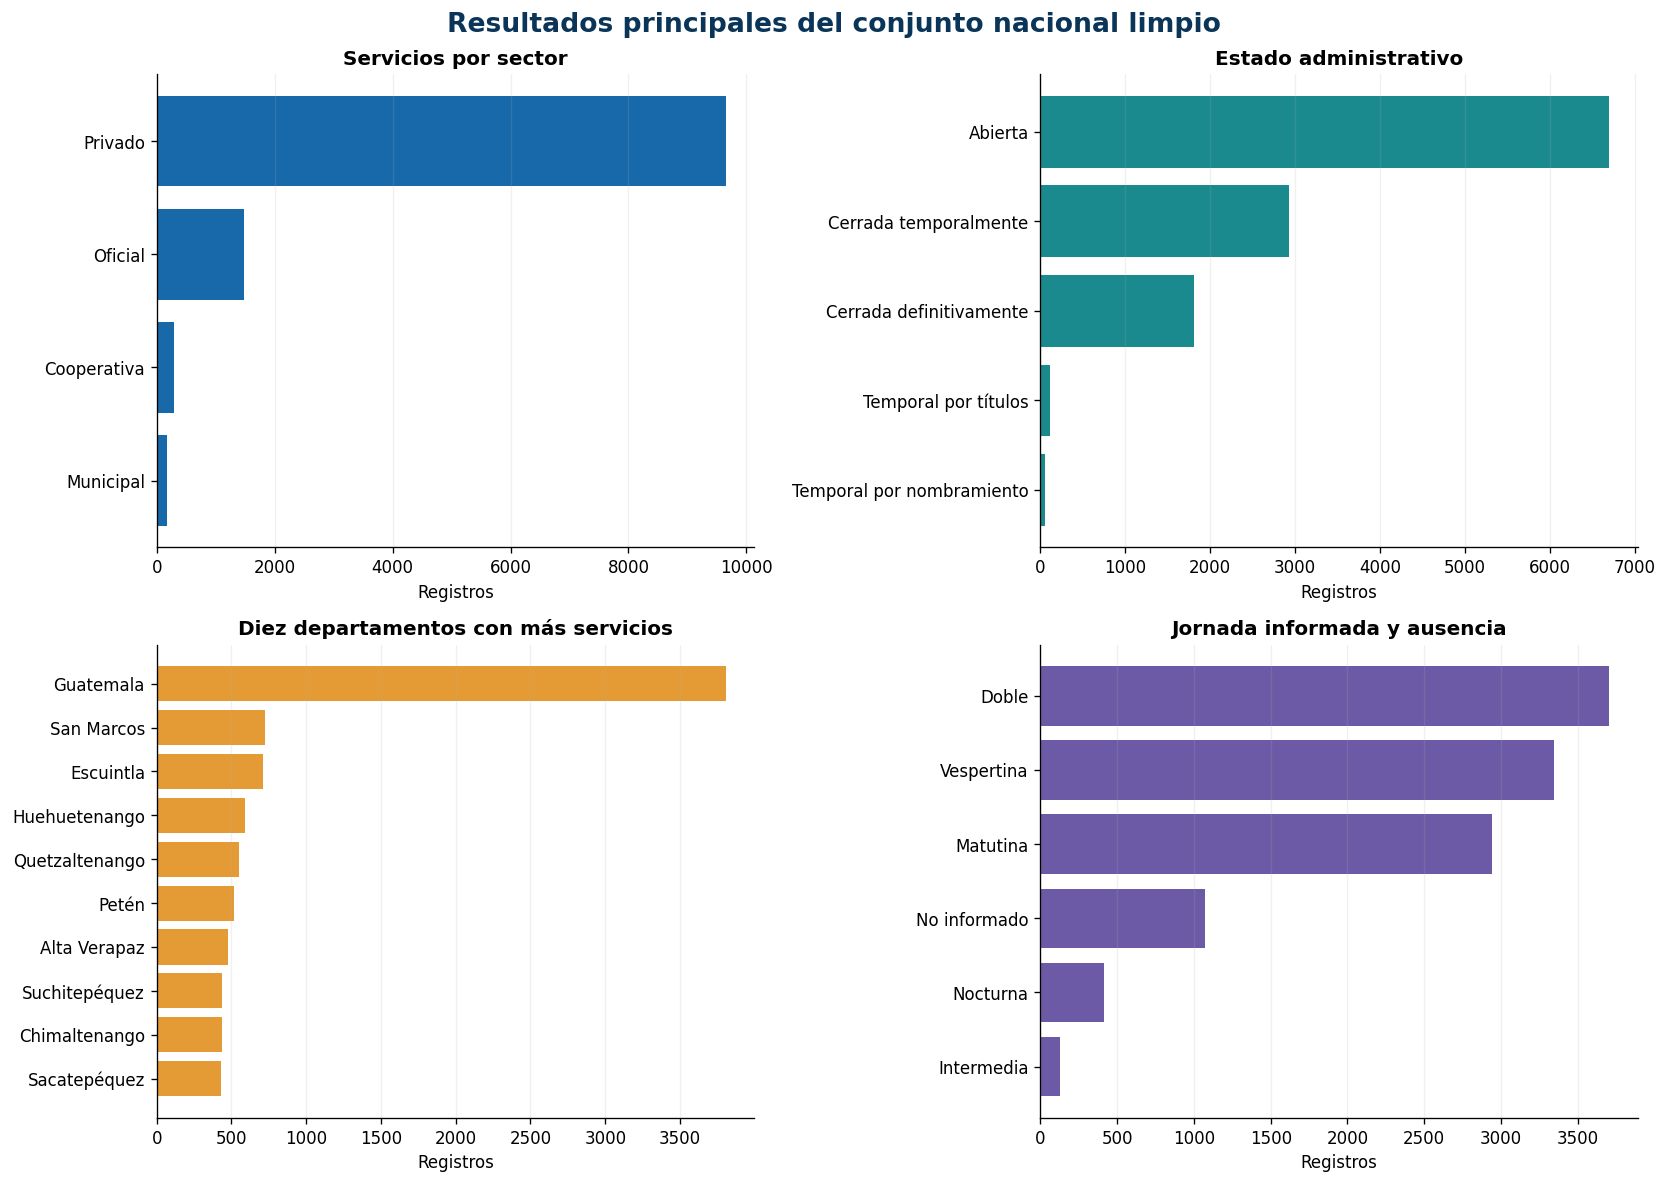

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sector_plot = dist_sector.sort_values("FILAS")
axes[0, 0].barh(sector_plot["CATEGORIA"], sector_plot["FILAS"], color=AZUL)
axes[0, 0].set_title("Servicios por sector", fontweight="bold")
axes[0, 0].set_xlabel("Registros")

status_plot = dist_status.sort_values("FILAS")
axes[0, 1].barh(status_plot["CATEGORIA"], status_plot["FILAS"], color=TURQUESA)
axes[0, 1].set_title("Estado administrativo", fontweight="bold")
axes[0, 1].set_xlabel("Registros")

dep_plot = dist_departamento.head(10).sort_values("FILAS")
axes[1, 0].barh(dep_plot["CATEGORIA"], dep_plot["FILAS"], color=NARANJA)
axes[1, 0].set_title("Diez departamentos con más servicios", fontweight="bold")
axes[1, 0].set_xlabel("Registros")

jornada_plot = dist_jornada.sort_values("FILAS")
axes[1, 1].barh(jornada_plot["CATEGORIA"], jornada_plot["FILAS"], color="#6c5aa7")
axes[1, 1].set_title("Jornada informada y ausencia", fontweight="bold")
axes[1, 1].set_xlabel("Registros")

for ax in axes.ravel():
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.18)

fig.suptitle("Resultados principales del conjunto nacional limpio", fontsize=16, fontweight="bold", color=AZUL_OSCURO)
plt.tight_layout()
fig.savefig(DIR_RESULTADOS / "resumen_distribuciones.png", dpi=180, bbox_inches="tight")
plt.show()


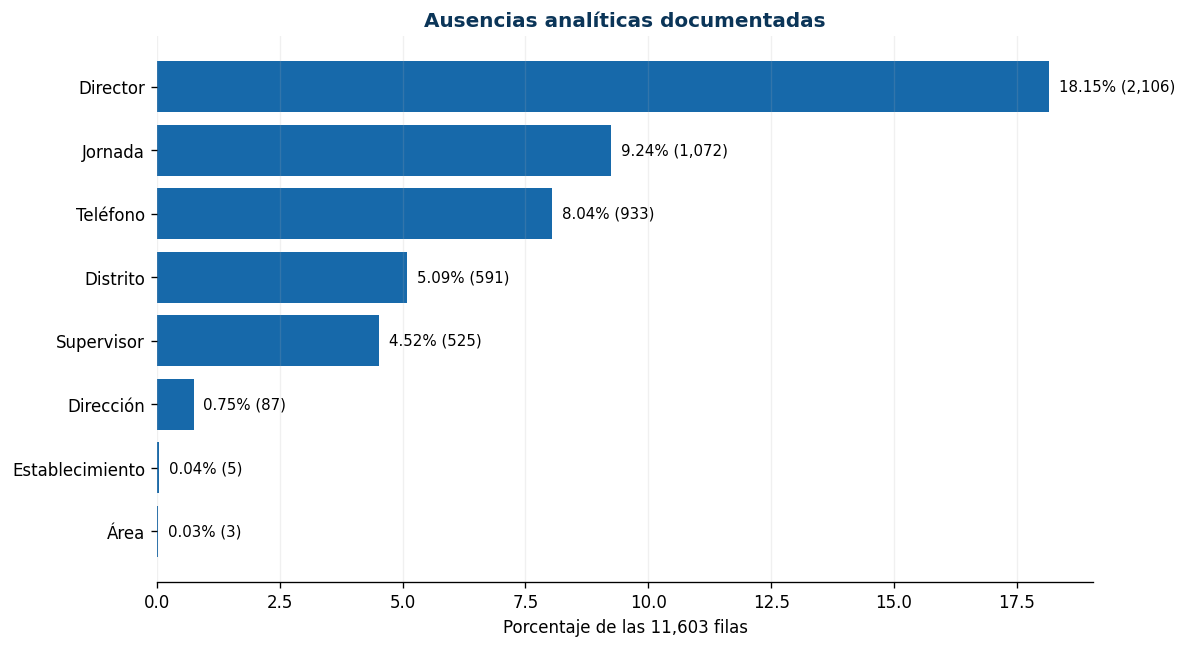

In [12]:
campos_null = [
    ("Distrito", int(limpio["DISTRITO_LIMPIO"].isna().sum())),
    ("Establecimiento", int(limpio["ESTABLECIMIENTO_LIMPIO"].isna().sum())),
    ("Dirección", int(limpio["DIRECCION_LIMPIA"].isna().sum())),
    ("Teléfono", int(limpio["TELEFONO_LIMPIO"].isna().sum())),
    ("Supervisor", int(limpio["SUPERVISOR_LIMPIO"].isna().sum())),
    ("Director", int(limpio["DIRECTOR_LIMPIO"].isna().sum())),
    ("Área", int(limpio["AREA_LIMPIA"].isna().sum())),
    ("Jornada", int(limpio["JORNADA_LIMPIA"].isna().sum())),
]
faltantes_resultado = pd.DataFrame(campos_null, columns=["VARIABLE", "NULL_ANALITICOS"])
faltantes_resultado["PORCENTAJE"] = (100 * faltantes_resultado["NULL_ANALITICOS"] / len(limpio)).round(2)

fig, ax = plt.subplots(figsize=(10, 5.5))
plot = faltantes_resultado.sort_values("PORCENTAJE")
ax.barh(plot["VARIABLE"], plot["PORCENTAJE"], color=AZUL)
for i, (pct, n) in enumerate(zip(plot["PORCENTAJE"], plot["NULL_ANALITICOS"])):
    ax.text(pct + 0.2, i, f"{pct:.2f}% ({n:,})", va="center", fontsize=9)
ax.set_title("Ausencias analíticas documentadas", fontweight="bold", color=AZUL_OSCURO)
ax.set_xlabel("Porcentaje de las 11,603 filas")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.18)
plt.tight_layout()
fig.savefig(DIR_RESULTADOS / "faltantes_analiticos.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. Interpretación de los resultados

La limpieza no pretende aumentar artificialmente la completitud. Su objetivo es **representar correctamente lo que se conoce y lo que no se conoce**, separar procedencia de agregación y producir etiquetas legibles sin destruir la evidencia original.

La tasa de conservación de registros se define como:

$$
T_{\mathrm{conservación}}=\frac{n_{\mathrm{limpio}}}{n_{\mathrm{crudo}}}\times 100=100\%.
$$

Los códigos categóricos creados son identificadores nominales. Si posteriormente se entrena un modelo, las variables nominales deberán transformarse mediante indicadores (*one-hot encoding*) y no utilizarse como si expresaran distancia.


In [13]:
abiertos = int(limpio["STATUS_LIMPIO"].eq("Abierta").sum())
privados = int(limpio["SECTOR_LIMPIO"].eq("Privado").sum())
urbanos = int(limpio["AREA_LIMPIA"].eq("Urbana").sum())
telefonos_interpretables = int(limpio["TELEFONO_PRINCIPAL"].notna().sum())

conclusiones = f'''
<div class='ds-card'>
  <h3>Conclusiones verificadas</h3>
  <ol style='line-height:1.65;color:#263746'>
    <li>Se conservaron <b>{len(limpio):,} de {len(datos):,} registros</b>; no existían duplicados exactos ni códigos repetidos.</li>
    <li>La vista de origen mantiene <b>23 categorías</b> y la vista analítica produce <b>22 departamentos</b> sin borrar la procedencia de Ciudad Capital.</li>
    <li><b>{abiertos:,}</b> servicios ({100*abiertos/len(limpio):.2f}%) se reportan abiertos.</li>
    <li>El sector privado reúne <b>{privados:,}</b> servicios ({100*privados/len(limpio):.2f}%) y el área urbana <b>{urbanos:,}</b> ({100*urbanos/len(limpio):.2f}%).</li>
    <li>Se identificó un teléfono principal de ocho dígitos en <b>{telefonos_interpretables:,}</b> filas; los formatos históricos no se rellenaron ni descartaron.</li>
    <li>DIRECTOR conserva la mayor ausencia analítica: <b>{limpio['DIRECTOR_LIMPIO'].isna().sum():,}</b> filas.</li>
    <li>Las etiquetas originales, las columnas limpias, los catálogos, la bitácora y las pruebas automáticas permiten reproducir y auditar cada transformación.</li>
  </ol>
</div>
'''
HTMLBlock(CSS_TABLA + conclusiones)


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 

 
   Conclusiones verificadas 
   
     Se conservaron  11,603 de 11,603 registros ; no existían duplicados exactos ni códigos repetidos. 
     La vista de origen mantiene  23 categorías  y la vista analítica produce  22 departamentos  sin borrar la procedencia de Ciudad Capital. 
      6,702  servicios (57.76%) se reportan abiertos. 
     El sector privado reúne  9,648  servicios (83.15%) y el área urbana  9,271  (79.90%). 
     Se identificó un teléfono principal de ocho dígitos en  10,566  filas; los formatos históricos no se rellenaron ni descartaron. 
     DIRECTOR conserva la mayor ausencia analítica:  2,106  filas. 
     Las etiquetas originales, las columnas limpias, los catálogos, la bitácora y las pruebas automáticas permiten reproducir y auditar cada transformación.

## 11. Limitaciones y uso responsable

- El archivo es una fotografía administrativa del portal y no demuestra que cada servicio continúe operando en la fecha de análisis.
- Los nombres de establecimientos y personas se normalizan de forma conservadora. Una corrección de identidad que no esté respaldada por la fuente requiere revisión manual u oficial.
- Los teléfonos con formatos antiguos o incompletos se conservan como texto y se marcan; no se inventan prefijos ni dígitos.
- `CIUDAD CAPITAL` es una procedencia válida de extracción. Su agrupación con Guatemala solo ocurre en `DEPARTAMENTO_ANALISIS`.
- Un nombre repetido no implica duplicación. `CODIGO` es la llave primaria del conjunto.